## Computation Analysis

Explore rough compute/runtime metrics for deployed LSTM and MPC benchmark runs.

Expected data root: `LSTM_training/data/latency_validation_data`

This notebook compares the available benchmark summaries for latency, core control compute time, and memory. Because we captured only one run per controller/map pair, the results should be treated as exploratory evidence rather than a statistical benchmark.

**TL;DR: the LSTM controller appears to be lower-latency for online control than a standad KMPC controller in these runs.**

## Setup/Imports


In [1]:
import json
import re
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 90)

DATA_ROOT = Path("../../data/latency_validation_data")
BASE_DIR = DATA_ROOT.resolve()

CONTROLLER_LABELS = {
    "lstm": "LSTM",
    "mpc": "MPC",
}

print(f"Data root: {DATA_ROOT}")
print(f"Base directory exists: {BASE_DIR.exists()}")


Data root: ../../data/latency_validation_data
Base directory exists: True


### Helpers

In [2]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_controller(controller):
    controller = str(controller).lower().strip()
    if "lstm" in controller:
        return "lstm"
    if "mpc" in controller:
        return "mpc"
    return controller


def controller_label(controller):
    return CONTROLLER_LABELS.get(controller, str(controller).upper())


def normalize_map_name(map_name):
    text = re.sub(r"\s+", " ", str(map_name).strip())
    aliases = {
        "ims": "IMS",
        "spielberg": "Spielberg",
    }
    return aliases.get(text.lower(), text.title())


def safe_get(data, key, default=np.nan):
    value = data.get(key, default)
    return default if value is None else value


def relative_to_base(path):
    try:
        return path.relative_to(BASE_DIR)
    except ValueError:
        return path


def read_npz_schema(path):
    rows = []
    try:
        with np.load(path, allow_pickle=True) as data:
            for key in data.files:
                arr = data[key]
                rows.append({
                    "key": key,
                    "shape": arr.shape,
                    "dtype": str(arr.dtype),
                })
    except zipfile.BadZipFile:
        rows.append({"key": "<file>", "shape": "", "dtype": "Corrupt .npz"})
    return pd.DataFrame(rows)


## Check Runs + Build Run Dataframes


In [3]:
run_records = []
skipped_dirs = []

for run_dir in sorted(path for path in BASE_DIR.iterdir() if path.is_dir()):
    compute_path = run_dir / "compute_summary.json"
    run_path = run_dir / "run_summary.json"
    log_path = run_dir / "driving_log.npz"

    if not (compute_path.exists() and run_path.exists() and log_path.exists()):
        skipped_dirs.append(run_dir)
        continue

    compute_summary = load_json(compute_path)
    run_summary = load_json(run_path)
    controller = normalize_controller(run_summary.get("controller_name", run_dir.name))
    map_display = normalize_map_name(run_summary.get("map_name", "unknown"))

    run_records.append({
        "run_dir": run_dir.name,
        "controller": controller,
        "controller_display": controller_label(controller),
        "map_display": map_display,
        "track_direction": run_summary.get("track_direction", "unknown"),
        "model_name": run_summary.get("model_name", "unknown"),
        "lap_completed": run_summary.get("lap_completed"),
        "collision": run_summary.get("collision"),
        "compute_path": compute_path,
        "run_path": run_path,
        "log_path": log_path,
        "display_path": relative_to_base(run_dir),
        "compute_summary": compute_summary,
        "run_summary": run_summary,
    })

df_runs = pd.DataFrame(run_records)

print(f"Cataloged {len(df_runs)} complete benchmark runs.")
print(f"Skipped {len(skipped_dirs)} incomplete run directories.")
display(df_runs[["run_dir", "controller_display", "map_display", "track_direction", "model_name", "lap_completed", "collision", "display_path"]])

if skipped_dirs:
    display(pd.DataFrame({"skipped_dir": [relative_to_base(path) for path in skipped_dirs]}))


Cataloged 4 complete benchmark runs.
Skipped 0 incomplete run directories.


,run_dir,controller_display,map_display,track_direction,model_name,lap_completed,collision,display_path
0,lstm_Spielberg_001,LSTM,Spielberg,normal,LSTM_H128_L1_EmbNoEmb_FC_128_64_32,True,False,lstm_Spielberg_001
1,lstm_ims_001,LSTM,IMS,normal,LSTM_H128_L1_EmbNoEmb_FC_128_64_32,True,False,lstm_ims_001
2,mpc_ims_gain2_001,MPC,IMS,normal,kmpc_n10_dt05,True,False,mpc_ims_gain2_001
3,mpc_spielberg_reverse_001,MPC,Spielberg,reverse,kmpc_n10_dt05,True,False,mpc_spielberg_reverse_001


Check the schema to confirm available data in run files.

In [4]:
if df_runs.empty:
    raise RuntimeError("No complete benchmark runs were found.")

sample_row = df_runs.iloc[0]
print(f"Sample run: {sample_row['run_dir']}")
print("compute_summary.json keys")
display(pd.DataFrame({"key": sorted(sample_row["compute_summary"].keys())}))
print("run_summary.json keys")
display(pd.DataFrame({"key": sorted(sample_row["run_summary"].keys())}))
print("driving_log.npz schema")
display(read_npz_schema(sample_row["log_path"]))


Sample run: lstm_Spielberg_001
compute_summary.json keys


,key
0,compute_profile_path
1,compute_tick_count
2,control_rate_hz_estimate
3,latency_max_ms
4,latency_mean_ms
5,latency_median_ms
6,latency_p95_ms
7,latency_p99_ms
8,missed_deadline_count
9,missed_deadline_rate


run_summary.json keys


,key
0,collision
1,compute_profile_path
2,compute_summary_path
3,compute_tick_count
4,control_rate_hz_estimate
5,controller_name
6,distance_traveled_m
7,driving_log_path
8,duration_s
9,lap_completed


driving_log.npz schema


,key,shape,dtype
0,timestamps,"(13175,)",float64
1,step_id,"(13175,)",int64
2,x,"(13175,)",float32
3,y,"(13175,)",float32
4,yaw,"(13175,)",float32
5,velocity,"(13175,)",float32
6,steering_angle,"(13175,)",float32
7,speed_command,"(13175,)",float32
8,collision_flag,"(13175,)",uint8
9,completion_flag,"(13175,)",uint8


## Metric Table

Build out a full dataframe with all metrics included, easier to call than from npz.

In [5]:
metric_records = []

for _, row in df_runs.iterrows():
    compute = row["compute_summary"]
    run = row["run_summary"]
    controller = row["controller"]

    core_prefix = "onnx" if controller == "lstm" else "solver" if controller == "mpc" else None
    core_label = "ONNX inference" if core_prefix == "onnx" else "MPC solver" if core_prefix == "solver" else "Core compute"

    duration_s = safe_get(run, "duration_s")
    lap_time_s = safe_get(run, "lap_time_s")
    compute_tick_count = safe_get(compute, "compute_tick_count")
    num_samples = safe_get(run, "num_samples")

    derived_tick_rate_hz = compute_tick_count / duration_s if duration_s and np.isfinite(duration_s) else np.nan
    derived_lap_tick_rate_hz = compute_tick_count / lap_time_s if lap_time_s and np.isfinite(lap_time_s) else np.nan
    sample_rate_hz = num_samples / duration_s if duration_s and np.isfinite(duration_s) else np.nan
    reported_rate_hz = safe_get(compute, "control_rate_hz_estimate")

    metric_records.append({
        "run_dir": row["run_dir"],
        "controller": controller,
        "controller_display": row["controller_display"],
        "map_display": row["map_display"],
        "track_direction": row["track_direction"],
        "model_name": row["model_name"],
        "lap_completed": row["lap_completed"],
        "collision": row["collision"],
        "lap_time_s": lap_time_s,
        "duration_s": duration_s,
        "distance_traveled_m": safe_get(run, "distance_traveled_m"),
        "mean_speed_mps": safe_get(run, "mean_speed_mps"),
        "max_speed_mps": safe_get(run, "max_speed_mps"),
        "mean_abs_steering_rad": safe_get(run, "mean_abs_steering_rad"),
        "mean_abs_steering_delta_rad": safe_get(run, "mean_abs_steering_delta_rad"),
        "compute_tick_count": compute_tick_count,
        "num_samples": num_samples,
        "reported_control_rate_hz": reported_rate_hz,
        "derived_tick_rate_hz": derived_tick_rate_hz,
        "derived_lap_tick_rate_hz": derived_lap_tick_rate_hz,
        "sample_rate_hz": sample_rate_hz,
        "latency_mean_ms": safe_get(compute, "latency_mean_ms"),
        "latency_median_ms": safe_get(compute, "latency_median_ms"),
        "latency_p95_ms": safe_get(compute, "latency_p95_ms"),
        "latency_p99_ms": safe_get(compute, "latency_p99_ms"),
        "latency_max_ms": safe_get(compute, "latency_max_ms"),
        "core_compute_label": core_label,
        "core_compute_mean_ms": safe_get(compute, f"{core_prefix}_mean_ms") if core_prefix else np.nan,
        "core_compute_median_ms": safe_get(compute, f"{core_prefix}_median_ms") if core_prefix else np.nan,
        "core_compute_p95_ms": safe_get(compute, f"{core_prefix}_p95_ms") if core_prefix else np.nan,
        "core_compute_p99_ms": safe_get(compute, f"{core_prefix}_p99_ms") if core_prefix else np.nan,
        "core_compute_max_ms": safe_get(compute, f"{core_prefix}_max_ms") if core_prefix else np.nan,
        "rss_peak_mb": safe_get(compute, "rss_peak_mb"),
        "missed_deadline_count": safe_get(compute, "missed_deadline_count"),
        "missed_deadline_rate": safe_get(compute, "missed_deadline_rate"),
        "scan_age_mean_ms": safe_get(compute, "scan_age_mean_ms"),
        "scan_age_p95_ms": safe_get(compute, "scan_age_p95_ms"),
        "odom_age_mean_ms": safe_get(compute, "odom_age_mean_ms"),
        "odom_age_p95_ms": safe_get(compute, "odom_age_p95_ms"),
    })

df_metrics = pd.DataFrame(metric_records).sort_values(["map_display", "controller_display"])

display(df_metrics)


,run_dir,controller,controller_display,map_display,track_direction,model_name,lap_completed,collision,lap_time_s,duration_s,distance_traveled_m,mean_speed_mps,max_speed_mps,mean_abs_steering_rad,mean_abs_steering_delta_rad,compute_tick_count,num_samples,reported_control_rate_hz,derived_tick_rate_hz,derived_lap_tick_rate_hz,sample_rate_hz,latency_mean_ms,latency_median_ms,latency_p95_ms,latency_p99_ms,latency_max_ms,core_compute_label,core_compute_mean_ms,core_compute_median_ms,core_compute_p95_ms,core_compute_p99_ms,core_compute_max_ms,rss_peak_mb,missed_deadline_count,missed_deadline_rate,scan_age_mean_ms,scan_age_p95_ms,odom_age_mean_ms,odom_age_p95_ms
1,lstm_ims_001,lstm,LSTM,IMS,normal,LSTM_H128_L1_EmbNoEmb_FC_128_64_32,True,False,101.260001,110.629971,295.883865,2.667734,2.906304,0.012297,0.002809,10551,10726,0.249728,95.371985,104.197115,96.953835,0.737888,0.722800,1.064424,1.204980,3.871912,ONNX inference,0.115243,0.108982,0.169328,0.201043,3.100084,134.710938,0,0.0,2.720847,4.500270,2.804538,4.515171
2,mpc_ims_gain2_001,mpc,MPC,IMS,normal,kmpc_n10_dt05,True,False,101.389945,111.600012,295.369765,2.636849,2.999903,0.012365,0.001286,2064,10737,19.999985,18.494622,20.357048,96.209667,1.376802,1.371801,2.010669,2.372689,2.753723,MPC solver,1.219667,1.196699,1.831309,2.163484,2.545400,85.328125,0,0.0,2.097187,3.086495,2.097187,3.086495
0,lstm_Spielberg_001,lstm,LSTM,Spielberg,normal,LSTM_H128_L1_EmbNoEmb_FC_128_64_32,True,False,129.989949,137.440016,351.611643,2.562265,2.927354,0.127038,0.009784,8426,13175,0.201036,61.306745,64.820396,95.860001,0.756736,0.740475,1.079197,1.221270,1.536970,ONNX inference,0.117347,0.112742,0.172599,0.202641,0.584127,134.453125,0,0.0,2.757585,4.512548,2.862383,4.524410
3,mpc_spielberg_reverse_001,mpc,MPC,Spielberg,reverse,kmpc_n10_dt05,True,False,125.360004,137.360031,344.181695,2.493116,2.999940,0.023011,0.002171,4685,13107,13.934923,34.107447,37.372366,95.420770,1.365897,1.375147,1.895180,2.085184,2.723175,MPC solver,1.199621,1.191475,1.694475,1.890263,2.537653,85.949219,0,0.0,2.023516,4.773855,2.793219,4.823017


Main Evidence for Compute Comparisons

Because this benchmark data only has one run per controller/map pair, the summary statistics are only preliminary. However, they still show the basic *latency*, core *compute*, and *memory* for each run. It is not unreasonable to assume these trends generalize across maps, but we are not making that claim.

In [6]:
headline_columns = [
    "map_display",
    "controller_display",
    "lap_time_s",
    "latency_mean_ms",
    "latency_p95_ms",
    "latency_p99_ms",
    "core_compute_label",
    "core_compute_mean_ms",
    "core_compute_p95_ms",
    "rss_peak_mb",
    "missed_deadline_rate",
]

display(
    df_metrics[headline_columns]
    .sort_values(["map_display", "controller_display"])
    .style.format({
        "lap_time_s": "{:.2f}",
        "latency_mean_ms": "{:.3f}",
        "latency_p95_ms": "{:.3f}",
        "latency_p99_ms": "{:.3f}",
        "core_compute_mean_ms": "{:.3f}",
        "core_compute_p95_ms": "{:.3f}",
        "rss_peak_mb": "{:.1f}",
        "missed_deadline_rate": "{:.3%}",
    })
)


,map_display,controller_display,lap_time_s,latency_mean_ms,latency_p95_ms,latency_p99_ms,core_compute_label,core_compute_mean_ms,core_compute_p95_ms,rss_peak_mb,missed_deadline_rate
1,IMS,LSTM,101.26,0.738,1.064,1.205,ONNX inference,0.115,0.169,134.7,0.000%
2,IMS,MPC,101.39,1.377,2.011,2.373,MPC solver,1.220,1.831,85.3,0.000%
0,Spielberg,LSTM,129.99,0.757,1.079,1.221,ONNX inference,0.117,0.173,134.5,0.000%
3,Spielberg,MPC,125.36,1.366,1.895,2.085,MPC solver,1.200,1.694,85.9,0.000%


## Rate Consistency Check

It seems our logger records or publishes or both at inconsistent rates. Without rerunning the suite (limited time), it's impossible to make a conclusion, this cell just visualizes how poorly distributed the rates are.

The reported control-rates do not line up cleanly with the rates derived from tick counts/total runtime. As such, we cannot use the reported rates as evidence for a faster or slower control rate.

In [7]:
df_quality = df_metrics.copy()
df_quality["rate_ratio_reported_to_derived"] = df_quality["reported_control_rate_hz"] / df_quality["derived_tick_rate_hz"]
df_quality["rate_discrepancy_pct"] = (
    (df_quality["reported_control_rate_hz"] - df_quality["derived_tick_rate_hz"]) / df_quality["derived_tick_rate_hz"] * 100
)

df_quality["rate_check"] = np.where(
    df_quality["rate_discrepancy_pct"].abs() > 25,
    "bad",
    "okay-ish",
)

display(
    df_quality[
        [
            "run_dir",
            "controller_display",
            "map_display",
            "reported_control_rate_hz",
            "derived_tick_rate_hz",
            "sample_rate_hz",
            "rate_discrepancy_pct",
            "rate_check",
        ]
    ].style.format({
        "reported_control_rate_hz": "{:.3f}",
        "derived_tick_rate_hz": "{:.1f}",
        "sample_rate_hz": "{:.1f}",
        "rate_discrepancy_pct": "{:.1f}%",
    })
)


,run_dir,controller_display,map_display,reported_control_rate_hz,derived_tick_rate_hz,sample_rate_hz,rate_discrepancy_pct,rate_check
1,lstm_ims_001,LSTM,IMS,0.250,95.4,97.0,-99.7%,bad
2,mpc_ims_gain2_001,MPC,IMS,20.000,18.5,96.2,8.1%,okay-ish
0,lstm_Spielberg_001,LSTM,Spielberg,0.201,61.3,95.9,-99.7%,bad
3,mpc_spielberg_reverse_001,MPC,Spielberg,13.935,34.1,95.4,-59.1%,bad


## Latency and Compute Plots


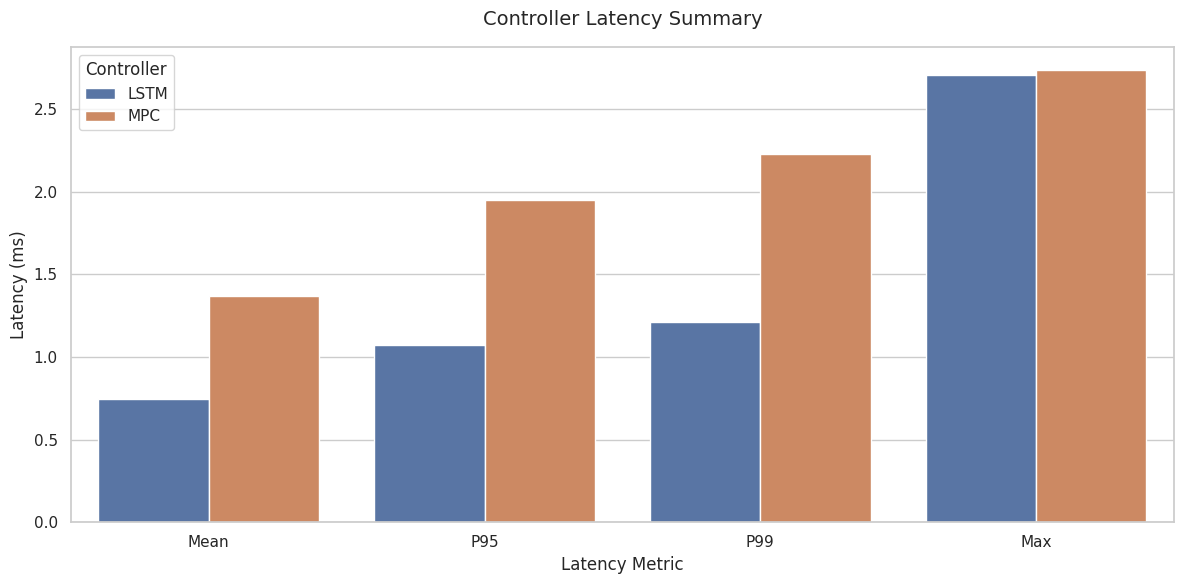

In [8]:
latency_long = df_metrics.melt(
    id_vars=["run_dir", "controller_display", "map_display"],
    value_vars=["latency_mean_ms", "latency_p95_ms", "latency_p99_ms", "latency_max_ms"],
    var_name="latency_metric",
    value_name="latency_ms",
)
latency_long["latency_metric"] = latency_long["latency_metric"].map({
    "latency_mean_ms": "Mean",
    "latency_p95_ms": "P95",
    "latency_p99_ms": "P99",
    "latency_max_ms": "Max",
})

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=latency_long,
    x="latency_metric",
    y="latency_ms",
    hue="controller_display",
    errorbar=None,
    ax=ax,
)
ax.set_title("Controller Latency Summary", fontsize=14, pad=16)
ax.set_xlabel("Latency Metric")
ax.set_ylabel("Latency (ms)")
ax.legend(title="Controller")
plt.tight_layout()
plt.show()


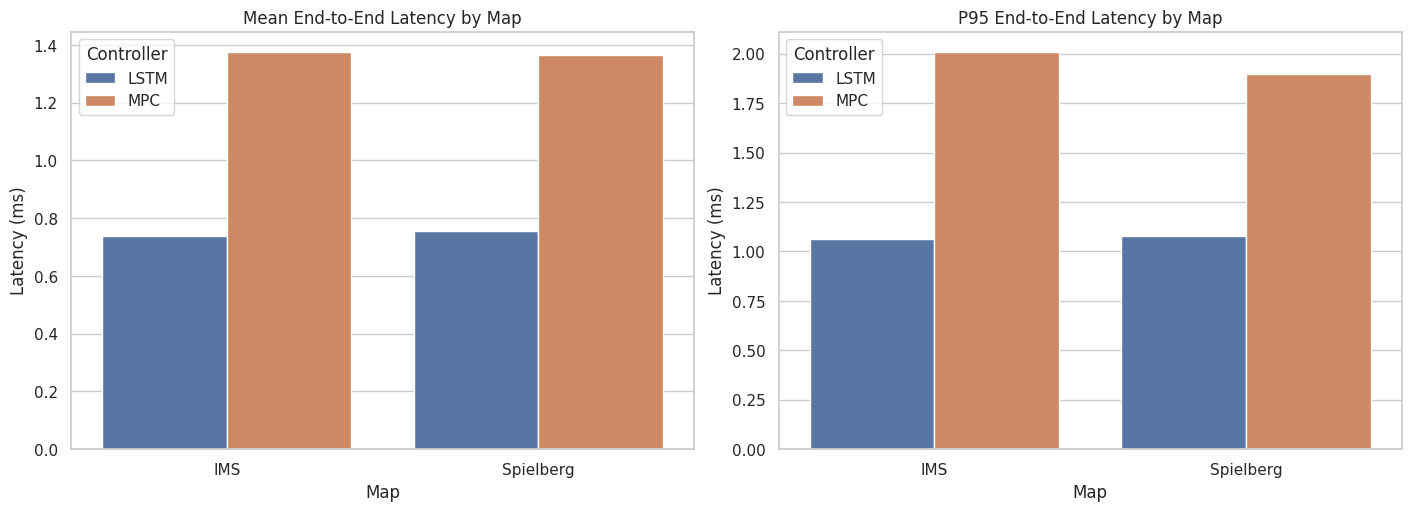

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.barplot(
    data=df_metrics,
    x="map_display",
    y="latency_mean_ms",
    hue="controller_display",
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Mean End-to-End Latency by Map")
axes[0].set_xlabel("Map")
axes[0].set_ylabel("Latency (ms)")
axes[0].legend(title="Controller")

sns.barplot(
    data=df_metrics,
    x="map_display",
    y="latency_p95_ms",
    hue="controller_display",
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("P95 End-to-End Latency by Map")
axes[1].set_xlabel("Map")
axes[1].set_ylabel("Latency (ms)")
axes[1].legend(title="Controller")

plt.show()


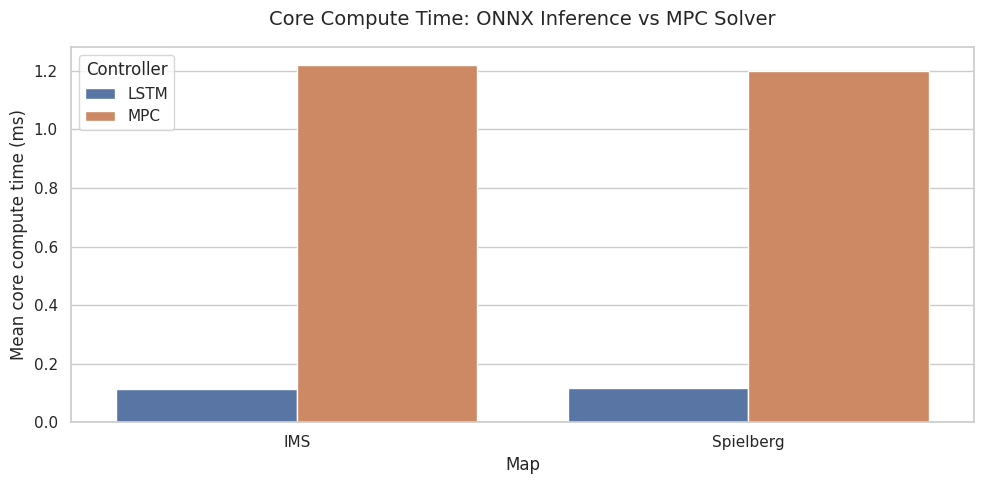

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=df_metrics,
    x="map_display",
    y="core_compute_mean_ms",
    hue="controller_display",
    errorbar=None,
    ax=ax,
)
ax.set_title("Core Compute Time: ONNX Inference vs MPC Solver", fontsize=14, pad=16)
ax.set_xlabel("Map")
ax.set_ylabel("Mean core compute time (ms)")
ax.legend(title="Controller")
plt.tight_layout()
plt.show()


Memory appears to be higher for LSTM here, althoguht it does include the ONNX runtime for local hardware runs. If running as a quantized TensorRT model, we presume the memory for the LSTM would drop significantly, although we have no proof.

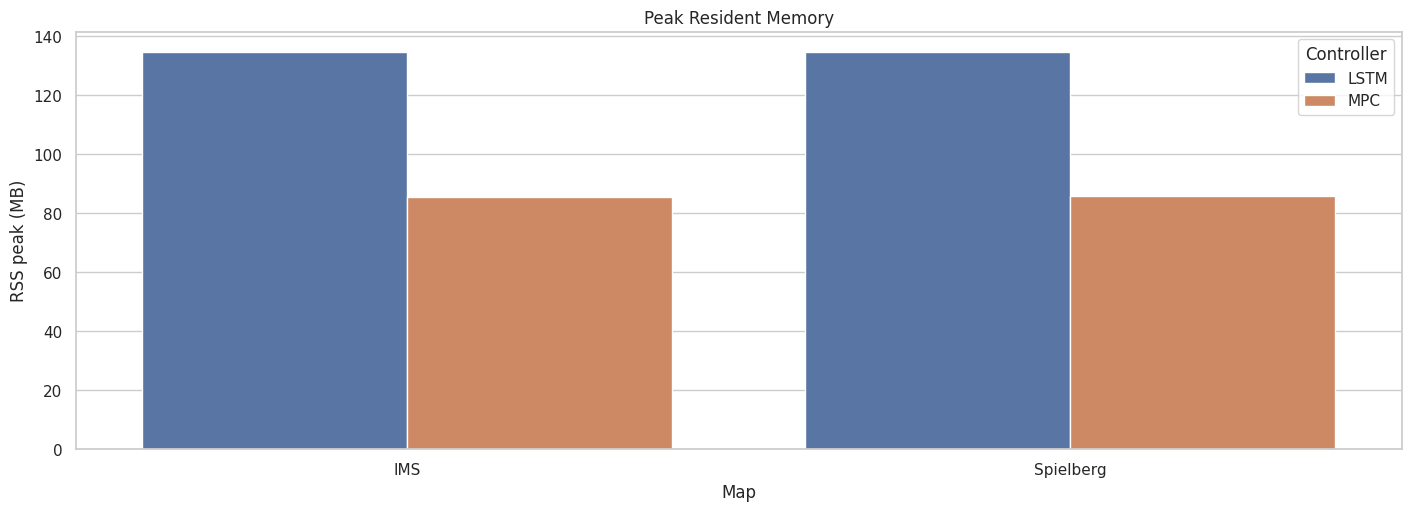

In [11]:
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

sns.barplot(
    data=df_metrics,
    x="map_display",
    y="rss_peak_mb",
    hue="controller_display",
    errorbar=None,
    ax=ax,
)
ax.set_title("Peak Resident Memory")
ax.set_xlabel("Map")
ax.set_ylabel("RSS peak (MB)")
ax.legend(title="Controller")

plt.show()


## Per-Map Ratios

Compares MPC directly against LSTM on the same map. Ratios above 1 means the MPC value was higher than the LSTM value (in terms of compute/latency, NOT race performance)

In [12]:
ratio_records = []
ratio_metrics = [
    "lap_time_s",
    "latency_mean_ms",
    "latency_p95_ms",
    "latency_p99_ms",
    "latency_max_ms",
    "core_compute_mean_ms",
    "core_compute_p95_ms",
    "rss_peak_mb",
    "derived_tick_rate_hz",
]

for map_display, group in df_metrics.groupby("map_display"):
    if set(group["controller"]) < {"lstm", "mpc"}:
        continue
    lstm_row = group[group["controller"] == "lstm"].iloc[0]
    mpc_row = group[group["controller"] == "mpc"].iloc[0]
    for metric in ratio_metrics:
        lstm_value = lstm_row[metric]
        mpc_value = mpc_row[metric]
        ratio_records.append({
            "map_display": map_display,
            "metric": metric,
            "lstm_value": lstm_value,
            "mpc_value": mpc_value,
            "mpc_over_lstm": mpc_value / lstm_value if lstm_value not in (0, np.nan) else np.nan,
        })

ratio_df = pd.DataFrame(ratio_records)
print("MPC / LSTM ratios by map. Values above 1 mean MPC is higher for that metric.")
display(
    ratio_df.pivot(index="metric", columns="map_display", values="mpc_over_lstm")
    .style.format("{:.2f}")
)


MPC / LSTM ratios by map. Values above 1 mean MPC is higher for that metric.


map_display,IMS,Spielberg
metric,,
core_compute_mean_ms,10.58,10.22
core_compute_p95_ms,10.82,9.82
derived_tick_rate_hz,0.19,0.56
lap_time_s,1.00,0.96
latency_max_ms,0.71,1.77
latency_mean_ms,1.87,1.80
latency_p95_ms,1.89,1.76
latency_p99_ms,1.97,1.71
rss_peak_mb,0.63,0.64


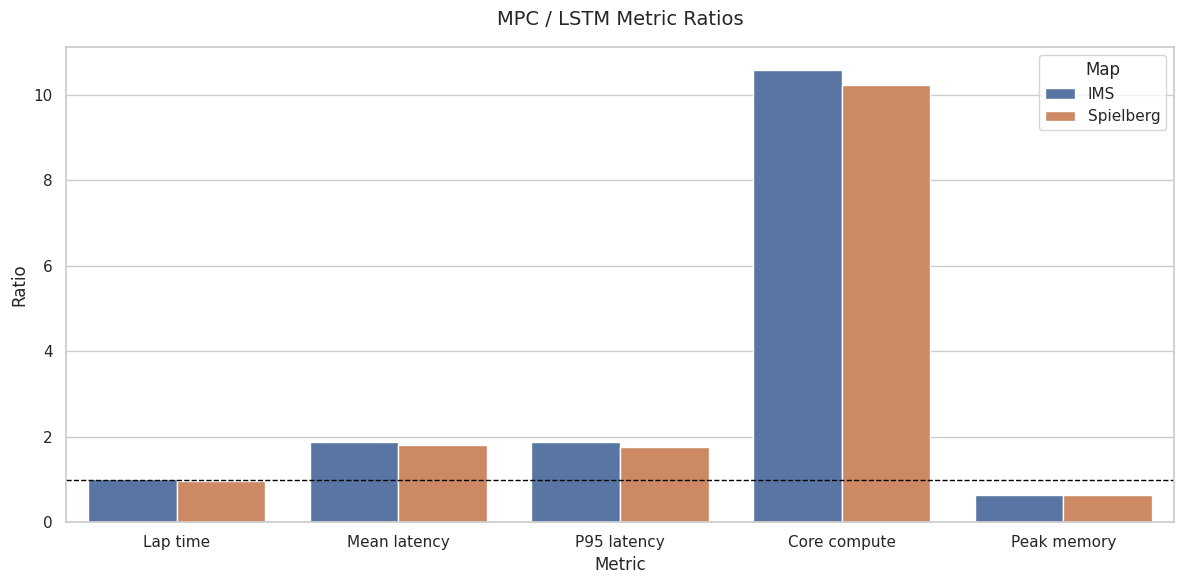

In [13]:
selected_ratio_metrics = ["latency_mean_ms", "latency_p95_ms", "core_compute_mean_ms", "rss_peak_mb", "lap_time_s"]
plot_ratio_df = ratio_df[ratio_df["metric"].isin(selected_ratio_metrics)].copy()
plot_ratio_df["metric_label"] = plot_ratio_df["metric"].map({
    "latency_mean_ms": "Mean latency",
    "latency_p95_ms": "P95 latency",
    "core_compute_mean_ms": "Core compute",
    "rss_peak_mb": "Peak memory",
    "lap_time_s": "Lap time",
})

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_ratio_df,
    x="metric_label",
    y="mpc_over_lstm",
    hue="map_display",
    errorbar=None,
    ax=ax,
)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_title("MPC / LSTM Metric Ratios", fontsize=14, pad=16)
ax.set_xlabel("Metric")
ax.set_ylabel("Ratio")
ax.legend(title="Map")
plt.tight_layout()
plt.show()


## Overall Summary

- The LSTM has lower compute latency. Across both maps, LSTM had lower mean callback latency: about 0.74-0.76 ms vs. 1.36-1.38 ms for KMPC.
- Not surprisingly (based on the above), the LSTM is faster to compute. LSTM ONNX inference: 0.115-0.117 ms, while the KMPC solver: 1.20-1.22 ms. 
   - MPC solve roughly 10x slower than LSTM inference
- This does **not** prove LSTM is lighter in memory. Peak memory was higher for LSTM, around 134 MB vs. 85-86 MB for KMPC.
  - Includes ONNX runtime, running in TensorRT may change this for the better (but again, we have no proof)

**If this trend is generalizable across maps: LSTM appears to be lower-latency for online control compute, but not lower-memory (when using ONNX runtime).**

*Main limitations: one run per controller/map pair, inconsistent rate estimates, and summary stats instead of raw per-tick traces.*

## Improvements
- repeated runs (duh) 
- raw timing logs
- CPU/GPU+CUDA usage
- identical timing boundaries (trim to exact start/finish line)
- RUN ON TENSORRT ON HARDWARE DUHHHH
